---

# Examination of "Prodicting Student Dropout Using Machine Learning Algorithms" by S. A. Sulak and N. Koklu

## Import Dependencies

In [1]:
from fastai.data.all import *
from fastai.metrics import accuracy, Recall, Precision, F1Score
from fastai.tabular.all import *
from fastai.text.all import *
from itertools import product
from mpl_toolkits.mplot3d import Axes3D
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import cross_validate
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import KFold
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
# from torchsummary import summary
import matplotlib.pyplot as plt 
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn

%matplotlib inline 
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


## Declare Utility Functions

In [26]:
def data_splitting(data, target):
    X_train_and_validate, X_test, t_train_and_validate, t_test = train_test_split(
        data, target, test_size=0.2, random_state=0
    )
    print("Train and Validate Data Shape:")
    print(X_train_and_validate.shape)
    print("Train and Validate Targets Shape:")
    print(t_train_and_validate.shape)
    print("Test Data Shape:")
    print(X_test.shape)
    print("Test Targets Shape:")
    print(t_test.shape)
    return X_train_and_validate, X_test, t_train_and_validate, t_test

def eval_report_from_obj(cv_results):
    print(u"Evaluation Report")
    print(u"---")
    print(u"Validation Accuracy: {:.3f} \u00B1 {:.3f}".format(cv_results['test_accuracy'].mean(), cv_results['test_accuracy'].std()))
    print(u"Validation Precision: {:.3f} \u00B1 {:.3f}".format(cv_results['test_precision_weighted'].mean(), cv_results['test_precision_weighted'].std()))
    print(u"Validation Recall: {:.3f} \u00B1 {:.3f}".format(cv_results['test_recall_weighted'].mean(), cv_results['test_recall_weighted'].std()))
    print(u"Validation F1: {:.3f} \u00B1 {:.3f}".format(cv_results['test_f1_weighted'].mean(), cv_results['test_f1_weighted'].std()))

def eval_report_from_targets_and_predicted_targets(targets, predicted_targets):
    print(u"Evaluation Report")
    print(u"---")
    print(u"Accuracy: {:.3f}".format(accuracy_score(targets, predicted_targets)))
    print(u"Precision: {:.3f}".format(precision_score(targets, predicted_targets, average='weighted')))
    print(u"Recall: {:.3f}".format(recall_score(targets, predicted_targets, average='weighted')))
    print(u"F1: {:.3f}".format(f1_score(targets, predicted_targets, average='weighted')))

def plot_test_accuracy(targets, predicted_targets, categories=None):
    sorted_idx = np.argsort(targets)
    plt.figure(figsize=(6,6))
    plt.scatter(sorted_idx, targets[sorted_idx], marker='o', c='red', label='target');
    plt.scatter(sorted_idx, predicted_targets[sorted_idx], marker='.', c='blue', label='prediction');
    plt.xlabel('Student Instances')
    plt.ylabel('Student Outcome')
    if categories is not None:
        plt.yticks([0, 1, 2], categories)
    plt.legend()
    plt.show()

def orig_hyper_param_value_to_search_values(num):
    search_values_length = 10
    multiplicand = num / 5
    search_values = []
    for i in range(search_values_length):
        multiplier = i + 1
        search_value = int(multiplicand * multiplier)
        if search_value < 2:
            search_value = 2
        if search_value not in search_values:
            search_values.append(search_value)
    return search_values


## Load Dataset

In [3]:
realinho_df = pd.read_csv("./realinho.csv", sep=";")
realinho_features = realinho_df.iloc[:, :-1]
realinho_targets = realinho_df.iloc[:, -1]

## Visualize Dataset

In [7]:
realinho_df

,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4419,1,1,6,9773,1,1,125.0,1,1,1,...,0,6,8,5,12.666667,0,15.5,2.8,-4.06,Graduate
4420,1,1,2,9773,1,1,120.0,105,1,1,...,0,6,6,2,11.000000,0,11.1,0.6,2.02,Dropout
4421,1,1,1,9500,1,1,154.0,1,37,37,...,0,8,9,1,13.500000,0,13.9,-0.3,0.79,Dropout
4422,1,1,1,9147,1,1,180.0,1,37,37,...,0,5,6,5,12.000000,0,9.4,-0.8,-3.12,Graduate


Note: Dataset imbalance is addressed at the algorithm level.


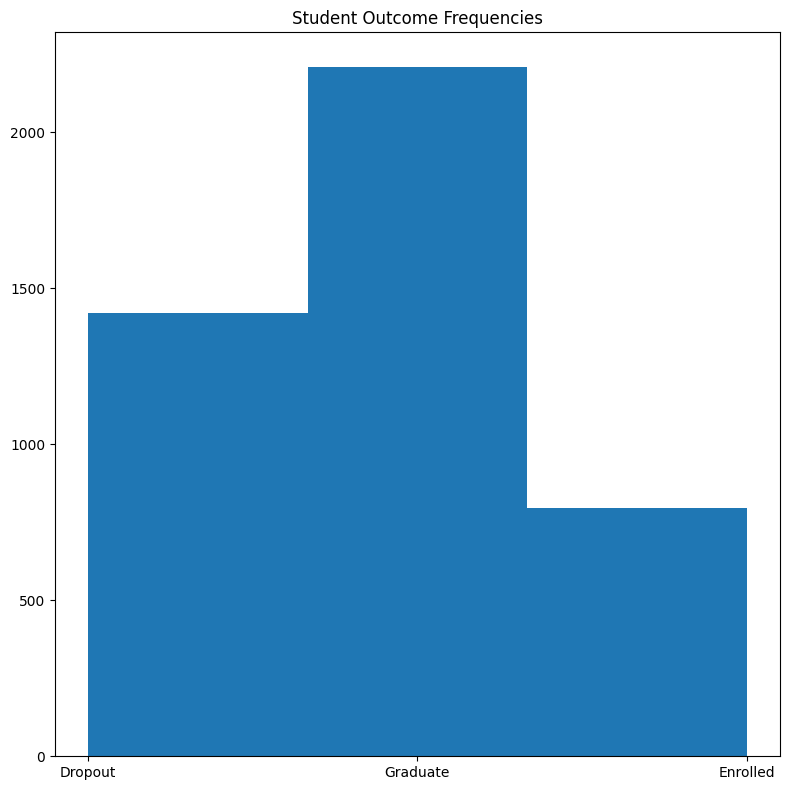

In [8]:
fig = plt.figure(figsize=(8,8))
plt.clf()
plt.hist(realinho_df[realinho_df.columns[-1]], bins=3)
plt.title("Student Outcome Frequencies")
fig.tight_layout()

print("Note: Dataset imbalance is addressed at the algorithm level.")

## Split Dataset

In [4]:
X_train_and_validate, X_test, t_train_and_validate, t_test = data_splitting(
    data=realinho_features,
    target=realinho_targets
)

Train and Validate Data Shape:
(3539, 36)
Train and Validate Targets Shape:
(3539,)
Test Data Shape:
(885, 36)
Test Targets Shape:
(885,)


## Decision Tree Classifier

### Perform K-Fold Cross-Validation Using Paper K-Fold Value & Hyperparameters

In [8]:
paper_hyper_parameters = {
    'max_depth': 100,
    'min_samples_split': 5,
    'min_samples_leaf': 2
}
print("Decision Tree hyperparameters arbitrarily selected by paper authors: max_depth={}, min_samples_leaf={}, min_samples_split={}".format(
    paper_hyper_parameters['max_depth'],
    paper_hyper_parameters['min_samples_leaf'],
    paper_hyper_parameters['min_samples_split']))

dt = DecisionTreeClassifier(class_weight='balanced', # Paper authors do not discuss how they dealt with class imbalance.
                            max_depth=paper_hyper_parameters['max_depth'], 
                            min_samples_leaf=paper_hyper_parameters['min_samples_leaf'],
                            min_samples_split=paper_hyper_parameters['min_samples_split'],
                            random_state=0)

k_fold=10
print("k-fold value used by paper authors: {}".format(k_fold))

my_cv_results = cross_validate(dt, X_train_and_validate, t_train_and_validate,
                            cv=k_fold,
                            scoring=['accuracy', 'precision_weighted', 'recall_weighted', 'f1_weighted'])

eval_report_from_obj(my_cv_results)

Decision Tree hyperparameters arbitrarily selected by paper authors: max_depth=100, min_samples_leaf=2, min_samples_split=5
k-fold value used by paper authors: 10
Evaluation Report
---
Validation Accuracy: 0.654 ± 0.023
Validation Precision: 0.675 ± 0.021
Validation Recall: 0.654 ± 0.023
Validation F1: 0.662 ± 0.021


### Test

In [11]:
print("The K-Fold cross validation results should indicate that the model is likely performant with the dataset.")
print("Therefore, train the model with all test and validate data.")
dt.fit(X_train_and_validate, t_train_and_validate)

The K-Fold cross validation results should indicate that the model is likely performant with the dataset.
Therefore, train the model with all test and validate data.


,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",100
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current n

#### My Results

Evaluation Report
---
Accuracy: 0.668
Precision: 0.706
Recall: 0.668
F1: 0.682


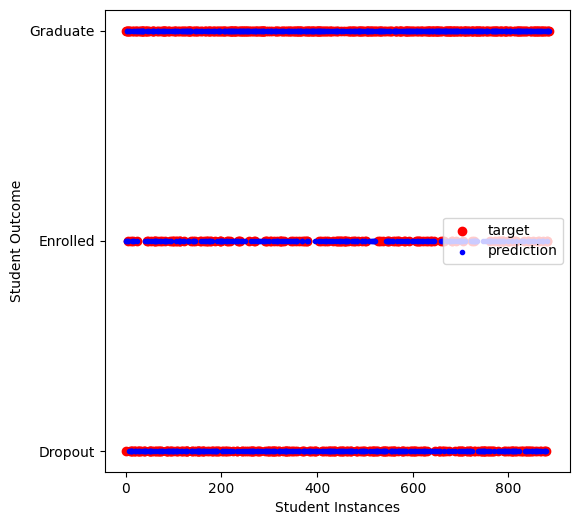

In [12]:
y_test_pred = dt.predict(X_test)
eval_report_from_targets_and_predicted_targets(t_test, y_test_pred)
plot_test_accuracy(t_test.values.to_numpy(), y_test_pred)

#### Paper Results

In [13]:
paper_test_results = {
    "test_accuracy": np.array([0.701]),
    "test_precision_weighted": np.array([0.7]),
    "test_recall_weighted": np.array([0.701]),
    "test_f1_weighted": np.array([0.7])
}
eval_report_from_obj(paper_test_results)

Evaluation Report
---
Validation Accuracy: 0.701 ± 0.000
Validation Precision: 0.700 ± 0.000
Validation Recall: 0.701 ± 0.000
Validation F1: 0.700 ± 0.000


### Attempt to Improve Test Results with Hyperparameter Search

In [14]:
my_hyper_parameter_options = {
    'max_depth': orig_hyper_param_value_to_search_values(paper_hyper_parameters['max_depth']),
    'min_samples_split': orig_hyper_param_value_to_search_values(paper_hyper_parameters['min_samples_split']),
    'min_samples_leaf': orig_hyper_param_value_to_search_values(paper_hyper_parameters['min_samples_leaf'])
}
print("Options for Hyperparameters Search:")
print("max_depth: {}".format(my_hyper_parameter_options['max_depth']))
print("min_samples_split: {}".format(my_hyper_parameter_options['min_samples_split']))
print("min_samples_leaf: {}".format(my_hyper_parameter_options['min_samples_leaf']))

gscv = GridSearchCV(dt, my_hyper_parameter_options, cv=k_fold)
gscv.fit(X_train_and_validate, t_train_and_validate)

print(f"Search Found these Best Hyperparameters: {gscv.best_params_}")

Options for Hyperparameters Search:
max_depth: [20, 40, 60, 80, 100, 120, 140, 160, 180, 200]
min_samples_split: [2, 3, 4, 5, 6, 7, 8, 9, 10]
min_samples_leaf: [2, 3, 4]
Search Found these Best Hyperparameters: {'max_depth': 20, 'min_samples_leaf': 3, 'min_samples_split': 2}


### Retest with Model Trained Using the New Hyperparameters on All Test and Validate Data 

Evaluation Report
---
Accuracy: 0.662
Precision: 0.700
Recall: 0.662
F1: 0.677


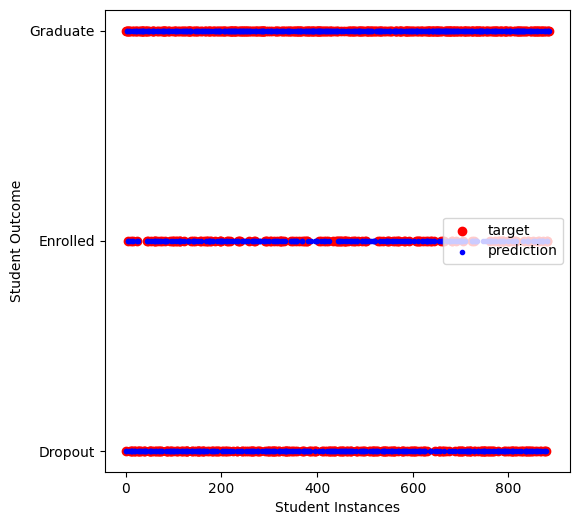

In [15]:
y_test_pred = gscv.predict(X_test)
eval_report_from_targets_and_predicted_targets(t_test, y_test_pred)
plot_test_accuracy(t_test.values.to_numpy(), y_test_pred)

## Random Forest

### Perform K-Fold Cross-Validation Using Paper K-Fold Value & Hyperparameters

In [16]:
paper_hyper_parameters = {
    'max_depth': 3,
    'max_features': 5,
    'min_samples_split': 5,
    'n_estimators': 10,
}
print("Random Forest hyperparameters arbitrarily selected by paper authors: n_estimators={}, max_depth={}, max_features={}, min_samples_split={}".format(
    paper_hyper_parameters['max_depth'],
    paper_hyper_parameters['max_features'],
    paper_hyper_parameters['min_samples_split'],
    paper_hyper_parameters['n_estimators']))

rf = RandomForestClassifier(max_depth=3,
                            max_features=5,
                            min_samples_split=5,
                            n_estimators=100,
                            oob_score=False,
                            class_weight='balanced', # Paper authors do not discuss how they dealt with class imbalance.
                            random_state=0)

print("k-fold value used by paper authors: {}".format(k_fold))

my_cv_results = cross_validate(rf, X_train_and_validate, t_train_and_validate,
                            cv=k_fold,
                            scoring=['accuracy', 'precision_weighted', 'recall_weighted', 'f1_weighted'])

eval_report_from_obj(my_cv_results)

Random Forest hyperparameters arbitrarily selected by paper authors: n_estimators=3, max_depth=5, max_features=5, min_samples_split=10
k-fold value used by paper authors: 10
Evaluation Report
---
Validation Accuracy: 0.729 ± 0.023
Validation Precision: 0.741 ± 0.023
Validation Recall: 0.729 ± 0.023
Validation F1: 0.732 ± 0.023


### Test

In [17]:
print("The K-Fold cross validation results should indicate that the model is likely performant with the dataset.")
print("Therefore, train the model with all test and validate data.")
rf.fit(X_train_and_validate, t_train_and_validate)

The K-Fold cross validation results should indicate that the model is likely performant with the dataset.
Therefore, train the model with all test and validate data.


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",5
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_true,

#### My Results

Evaluation Report
---
Accuracy: 0.749
Precision: 0.762
Recall: 0.749
F1: 0.752


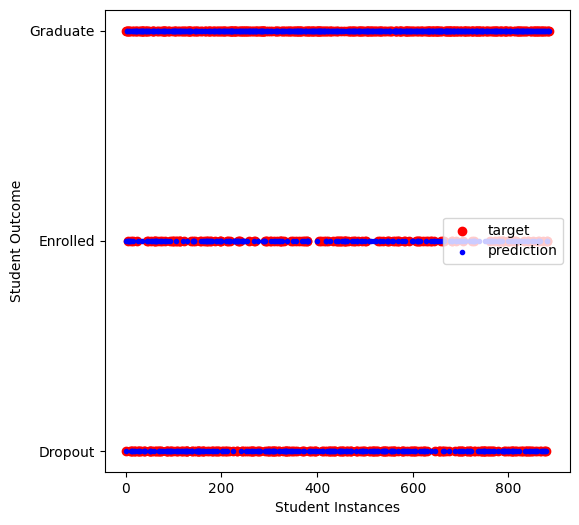

In [18]:
y_test_pred = rf.predict(X_test)
eval_report_from_targets_and_predicted_targets(t_test, y_test_pred)
plot_test_accuracy(t_test.values.to_numpy(), y_test_pred)

#### Paper Results

In [19]:
paper_test_results = {
    "test_accuracy": np.array([0.755]),
    "test_precision_weighted": np.array([0.739]),
    "test_recall_weighted": np.array([0.755]),
    "test_f1_weighted": np.array([0.742])
}
eval_report_from_obj(paper_test_results)

Evaluation Report
---
Validation Accuracy: 0.755 ± 0.000
Validation Precision: 0.739 ± 0.000
Validation Recall: 0.755 ± 0.000
Validation F1: 0.742 ± 0.000


### Attempt to Improve Test Results with Hyperparameter Search

In [20]:
my_hyper_parameter_options = {
    'max_depth': orig_hyper_param_value_to_search_values(paper_hyper_parameters['max_depth']),
    'max_features': orig_hyper_param_value_to_search_values(paper_hyper_parameters['max_features']),
    'min_samples_split': orig_hyper_param_value_to_search_values(paper_hyper_parameters['min_samples_split']),
    'n_estimators': orig_hyper_param_value_to_search_values(paper_hyper_parameters['n_estimators'])
}
print("Options for Hyperparameters Search:")
print("max_depth: {}".format(my_hyper_parameter_options['max_depth']))
print("max_features: {}".format(my_hyper_parameter_options['max_features']))
print("min_samples_split: {}".format(my_hyper_parameter_options['min_samples_split']))
print("n_estimators: {}".format(my_hyper_parameter_options['n_estimators']))

gscv = GridSearchCV(rf, my_hyper_parameter_options, cv=k_fold)
gscv.fit(X_train_and_validate, t_train_and_validate)

print(f"Search Found these Best Hyperparameters: {gscv.best_params_}")

Options for Hyperparameters Search:
max_depth: [2, 3, 4, 5, 6]
max_features: [2, 3, 4, 5, 6, 7, 8, 9, 10]
min_samples_split: [2, 3, 4, 5, 6, 7, 8, 9, 10]
n_estimators: [2, 4, 6, 8, 10, 12, 14, 16, 18, 20]
Search Found these Best Hyperparameters: {'max_depth': 6, 'max_features': 9, 'min_samples_split': 4, 'n_estimators': 20}


### Retest with Model Trained Using the New Hyperparameters on All Test and Validate Data 

Evaluation Report
---
Accuracy: 0.750
Precision: 0.785
Recall: 0.750
F1: 0.761


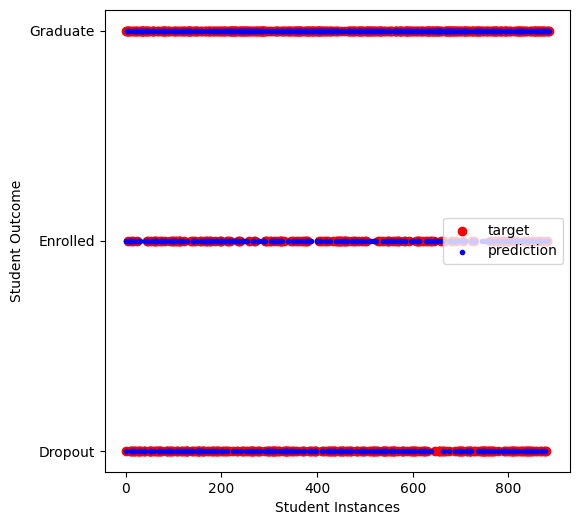

In [21]:
y_test_pred = gscv.predict(X_test)
eval_report_from_targets_and_predicted_targets(t_test, y_test_pred)
plot_test_accuracy(t_test.values.to_numpy(), y_test_pred)

## Artificial Neural Network

### Adjust Train/Validate & Test Datasets for Artificial Neural Network Training

In [5]:
X_train_and_validate_with_target = X_train_and_validate.copy()
X_train_and_validate_with_target[realinho_df.columns[-1]] = t_train_and_validate.values

X_test_with_target = X_test.copy()
X_test_with_target[realinho_df.columns[-1]] = t_test.values

### Perform K-Fold Cross-Validation Using Paper K-Fold Value & Hyperparameters

In [ ]:
paper_hyper_parameters = {
    'activation_fn': nn.Sigmoid(), # Function used in Logistic Regression. Paper authors identify their activation function of choice with word "Logistic".
    'layers': [100, 100, 100], # Authors don't specify this. I chose 3 hidden layers with 100 neurons each to give the model enough capacity to learn the data without overfitting.
    'learning_rate': 0.1, # Authors don't specify this.
    'max_iterations': 200,
    'neurons_in_hidden_layer': 100,
    'opt_func': Adam,
    'regularization': 0,
}
print("Artificial Neural Network hyperparameters arbitrarily selected by paper authors: activation_fn={}, max_iterations={}, neurons_in_hidden_layer={}, regularization={}, opt_func={}".format(
    paper_hyper_parameters['activation_fn'],
    paper_hyper_parameters['max_iterations'],
    paper_hyper_parameters['neurons_in_hidden_layer'],
    paper_hyper_parameters['regularization'],
    paper_hyper_parameters['opt_func']))

print("k-fold value used by paper authors: {}".format(k_fold))

batch_size = 64 # Paper authors don't specify a batch size.

kf = KFold(n_splits=k_fold, shuffle=True, random_state=0)
my_cv_results = {
    'test_accuracy': np.array([]),
    'test_precision_weighted': np.array([]),
    'test_recall_weighted': np.array([]),
    'test_f1_weighted': np.array([])
}
for fold, (train_idx, val_idx) in enumerate(kf.split(X_train_and_validate_with_target)):
    # Create splits per fold
    splits = (list(train_idx), list(val_idx))
    
    tp = TabularPandas(
        # Providing a copy resolves this execution time warning:
        # "UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors."
        X_train_and_validate_with_target.copy(),
        procs=[Categorify, Normalize], 
        cat_names=X_train_and_validate.select_dtypes(include="object").columns.to_list(), 
        cont_names=X_train_and_validate.select_dtypes(exclude="object").columns.to_list(), 
        y_names=X_train_and_validate_with_target.columns[-1],
        splits=splits,  # Use the specific fold splits
    )
    
    dls = tp.dataloaders(bs=batch_size)
    learner = tabular_learner(dls,
                            config={'act_cls': paper_hyper_parameters['activation_fn']},
                            layers=paper_hyper_parameters['layers'],
                            metrics=[accuracy, Recall(average='weighted'),
                                       Precision(average='weighted'),
                                       F1Score(average='weighted')],
                            opt_func=paper_hyper_parameters['opt_func'],
                            wd=paper_hyper_parameters['regularization']
                            )
    learner.to(device)
    with learner.no_bar():
        learner.fit(paper_hyper_parameters['max_iterations'])
    
    validation_result = learner.validate()
    my_cv_results['test_accuracy'] = np.append(my_cv_results['test_accuracy'], validation_result[1])
    my_cv_results['test_precision_weighted'] = np.append(my_cv_results['test_precision_weighted'], validation_result[2])
    my_cv_results['test_recall_weighted'] = np.append(my_cv_results['test_recall_weighted'], validation_result[3])
    my_cv_results['test_f1_weighted'] = np.append(my_cv_results['test_f1_weighted'], validation_result[4])

eval_report_from_obj(my_cv_results)

Artificial Neural Network hyperparameters arbitrarily selected by paper authors: activation_fn=Sigmoid(), max_iterations=200, neurons_in_hidden_layer=100, regularization=0, opt_func=<function Adam at 0x7d1fadf07420>


NameError: name 'k_fold' is not defined

### Test

In [ ]:
print("The K-Fold cross validation results should indicate that the model is likely performant with the dataset.")
print("Therefore, train the model with all test and validate data.")
splits = None  # No split, all data for training.
tp = TabularPandas(
    # Providing a copy resolves this execution time warning:
    # "UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors."
    X_train_and_validate_with_target.copy(), 
    procs=[Categorify, Normalize], 
    cat_names=X_train_and_validate.select_dtypes(include="object").columns.to_list(), 
    cont_names=X_train_and_validate.select_dtypes(exclude="object").columns.to_list(), 
    y_names=X_train_and_validate_with_target.columns[-1],
    splits=splits,
)
dls = tp.dataloaders(bs=batch_size)
learner = tabular_learner(dls,
                            config={'act_cls': paper_hyper_parameters['activation_fn']},
                            layers=paper_hyper_parameters['layers'],
                            metrics=[accuracy, Recall(average='weighted'),
                                       Precision(average='weighted'),
                                       F1Score(average='weighted')],
                            opt_func=paper_hyper_parameters['opt_func'],
                            wd=paper_hyper_parameters['regularization']
                        )
learner.to(device)
with learner.no_bar():                        
    learner.fit(paper_hyper_parameters['max_iterations'], lr=paper_hyper_parameters['learning_rate']) 

The K-Fold cross validation results should indicate that the model is likely performant with the dataset.
Therefore, train the model with all test and validate data.


<div></div>

/home/raymond/src/itcs-5154-project/.venv/lib/python3.12/site-packages/fastprogress/fastprogress.py:93: UserWarning: Your generator is empty.
  warn("Your generator is empty.")
/home/raymond/src/itcs-5154-project/.venv/lib/python3.12/site-packages/fastprogress/fastprogress.py:93: UserWarning: Your generator is empty.
  warn("Your generator is empty.")
/home/raymond/src/itcs-5154-project/.venv/lib/python3.12/site-packages/fastprogress/fastprogress.py:93: UserWarning: Your generator is empty.
  warn("Your generator is empty.")
/home/raymond/src/itcs-5154-project/.venv/lib/python3.12/site-packages/fastprogress/fastprogress.py:93: UserWarning: Your generator is empty.
  warn("Your generator is empty.")
/home/raymond/src/itcs-5154-project/.venv/lib/python3.12/site-packages/fastprogress/fastprogress.py:93: UserWarning: Your generator is empty.
  warn("Your generator is empty.")
/home/raymond/src/itcs-5154-project/.venv/lib/python3.12/site-packages/fastprogress/fastprogress.py:93: UserWarning

#### My Results

Evaluation Report
---
Accuracy: 0.701
Precision: 0.594
Recall: 0.701
F1: 0.639


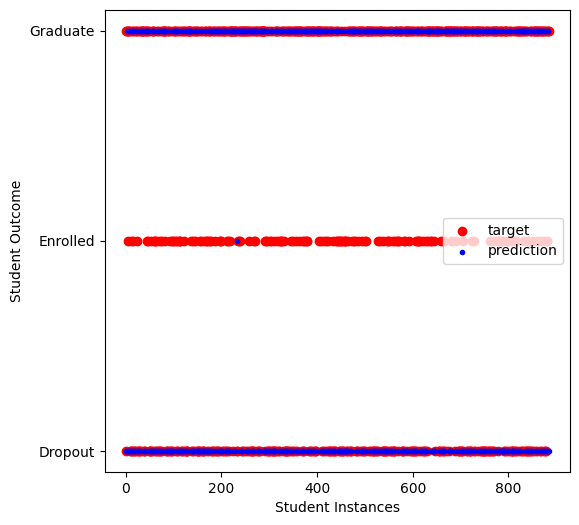

In [25]:
_, targets, predicted_targets = learner.get_preds(dl=dls.test_dl(X_test_with_target), with_decoded=True)
targets = targets.numpy().flatten()
predicted_targets = predicted_targets.numpy()
eval_report_from_targets_and_predicted_targets(targets, predicted_targets)
plot_test_accuracy(targets, predicted_targets, dls.vocab)

#### Paper Results

In [ ]:
paper_test_results = {
    "test_accuracy": np.array([0.773]),
    "test_precision_weighted": np.array([0.76]),
    "test_recall_weighted": np.array([0.773]),
    "test_f1_weighted": np.array([0.762])9
}
eval_report_from_obj(paper_test_results)

Evaluation Report
---
Validation Accuracy: 0.773 ± 0.000
Validation Precision: 0.760 ± 0.000
Validation Recall: 0.773 ± 0.000
Validation F1: 0.762 ± 0.000


## Attempt to Improve Test Results with Hyperparameter Search

In [ ]:
my_hyper_parameter_options = {
    'activation_fn': [nn.Sigmoid(), nn.ReLU(), nn.Tanh()],
    'layers': [[50, 50, 50], [100, 100, 100], [150, 150, 150]],
    'learning_rate': [0.05, 0.1, 0.2],
    'max_iterations': [100, 150, 200],
    'opt_func': [Adam, SGD],
    'regularization': [0, 0.01, 0.1],
}

splitter = RandomSplitter(valid_pct=0.1, seed=1)
splits = splitter(X_train_and_validate_with_target)
tp = TabularPandas(
    X_train_and_validate_with_target, 
    procs=[Categorify, Normalize], 
    cat_names=X_train_and_validate.select_dtypes(include="object").columns.to_list(), 
    cont_names=X_train_and_validate.select_dtypes(exclude="object").columns.to_list(), 
    y_names=X_train_and_validate_with_target.columns[-1],
    splits=splits
)
dls = tp.dataloaders(bs=batch_size)

best_accuracy_score = 0
best_found_hyper_parameters = {}

for activation_fn, layers, max_iterations, opt_func, regularization, lr in product(my_hyper_parameter_options['activation_fn'],
                                                                                   my_hyper_parameter_options['layers'],
                                                                                   my_hyper_parameter_options['max_iterations'],
                                                                                   my_hyper_parameter_options['opt_func'],
                                                                                   my_hyper_parameter_options['regularization'],
                                                                                   my_hyper_parameter_options['learning_rate']):
    learner = tabular_learner(dls,
                              config={'act_cls': activation_fn},
                              layers=layers,
                              metrics=accuracy,
                              opt_func=opt_func,
                              wd=regularization
                              )
    learner.to(device)
    with learner.no_bar:
        learner.fit(max_iterations, lr=lr)
    
    val_loss, *val_metrics = learner.validate()
    current_accuracy_score = val_metrics[0]  # Use accuracy as the score
    
    if current_accuracy_score > best_accuracy_score:
        best_accuracy_score = current_accuracy_score
        best_found_hyper_parameters = {'activation_fn': activation_fn,
                                       'layers': layers,
                                       'max_iterations': max_iterations,
                                       'opt_func': opt_func,
                                       'regularization': regularization,
                                       'learning_rate': lr}
print(f"Search Found these Best Hyperparameters: {best_found_hyper_parameters}")

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div></div>

<div><div><progress max="200" value="21"></progress> 10.50% [21/200 00:04&lt;00:40]</div><div></div><div><progress max="49" value="0"></progress> 0.00% [0/49 00:00&lt;?]</div></div>

### Retest with Model Trained Using the New Hyperparameters on All Test and Validate Data 

In [ ]:
splits = None  # No split, all data for training.
tp = TabularPandas(
    X_train_and_validate_with_target, 
    procs=[Categorify, Normalize], 
    cat_names=X_train_and_validate.select_dtypes(include="object").columns.to_list(), 
    cont_names=X_train_and_validate.select_dtypes(exclude="object").columns.to_list(), 
    y_names=X_train_and_validate_with_target.columns[-1],
    splits=splits
)
learner = tabular_learner(dls,
                            config={'act_cls': best_found_hyper_parameters['activation_fn']},
                            layers=best_found_hyper_parameters['layers'],
                            metrics=accuracy,
                            opt_func=best_found_hyper_parameters['opt_func'],
                            wd=best_found_hyper_parameters['regularization']
                        )
learner.to(device)
with learner.no_bar():
    learner.fit(best_found_hyper_parameters['max_iterations'], lr=best_found_hyper_parameters['learning_rate'])

predictions, targets, predicted_targets = learner.get_preds(dl=dls.test_dl(X_test_with_target), with_decoded=True)
targets = targets.numpy().flatten()   
predicted_targets = predicted_targets.numpy()

eval_report_from_targets_and_predicted_targets(targets, predicted_targets)
plot_test_accuracy(targets, predicted_targets, dls.vocab)

<div></div>

Evaluation Report
---


TypeError: 'float' object is not callable